Train Shape: (891, 12)
Test Shape: (418, 11)


/tmp/ipykernel_8226/1093189213.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Age'].fillna(train['Age'].median(), inplace=True)
/tmp/ipykernel_8226/1093189213.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

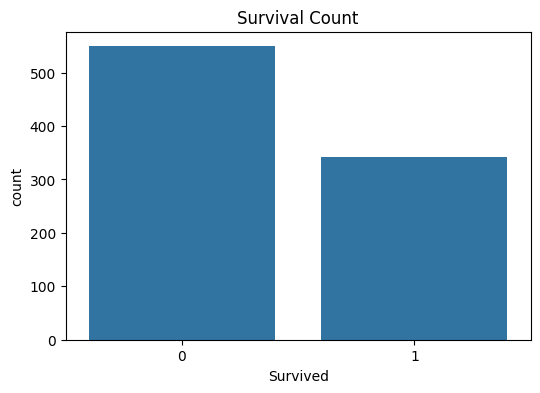

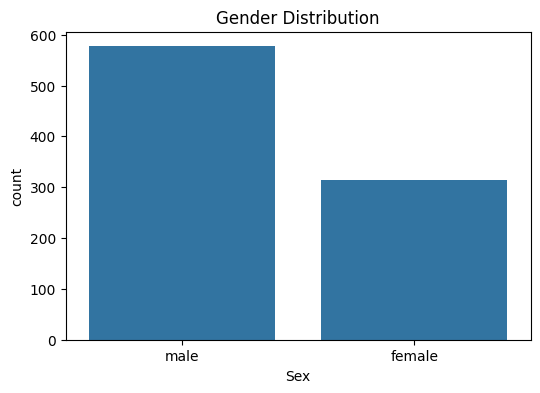

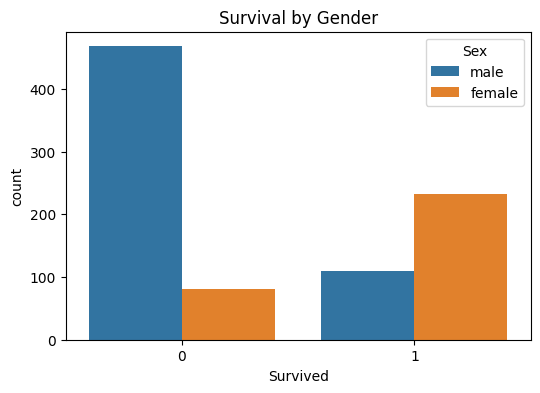

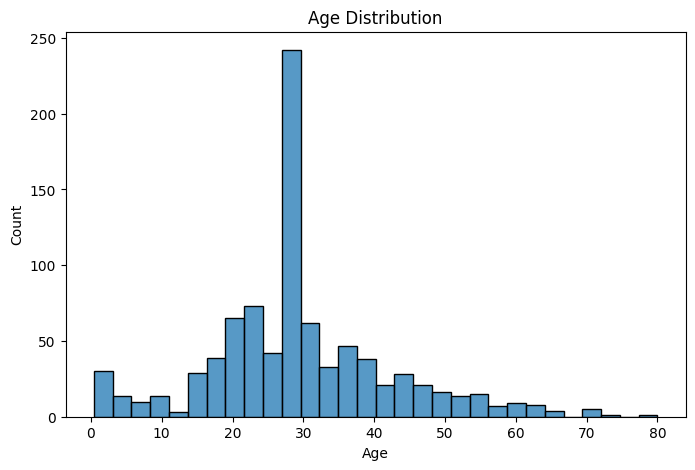

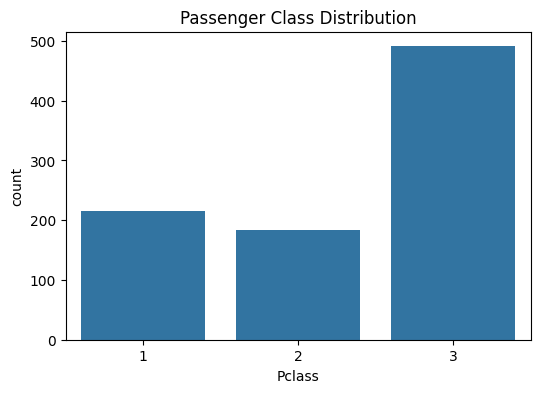


Model Accuracy: 82.12 %

Feature Importance:
    Feature  Importance
1       Sex    0.271410
5      Fare    0.265010
2       Age    0.249995
0    Pclass    0.086957
3     SibSp    0.053685
4     Parch    0.039897
6  Embarked    0.033044


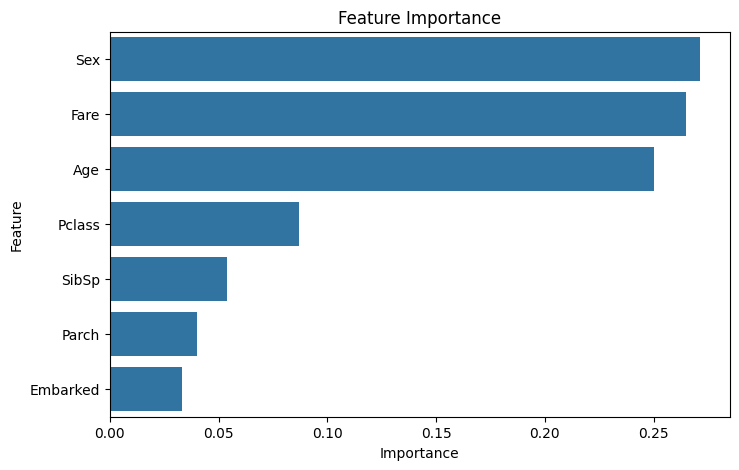


submission.csv created successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
# Titanic Survival Prediction Project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load Dataset
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

# Missing Values
train['Age'].fillna(train['Age'].median(), inplace=True)
train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)
train['Cabin'].fillna("Unknown", inplace=True)

test['Age'].fillna(test['Age'].median(), inplace=True)
test['Fare'].fillna(test['Fare'].median(), inplace=True)
test['Cabin'].fillna("Unknown", inplace=True)
test['Embarked'].fillna(test['Embarked'].mode()[0], inplace=True)

# Visualizations

plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=train)
plt.title("Survival Count")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='Sex', data=train)
plt.title("Gender Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='Survived', hue='Sex', data=train)
plt.title("Survival by Gender")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(train['Age'], bins=30)
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', data=train)
plt.title("Passenger Class Distribution")
plt.show()

# Encode Categorical Columns
le = LabelEncoder()

train['Sex'] = le.fit_transform(train['Sex'])
train['Embarked'] = le.fit_transform(train['Embarked'])

test['Sex'] = le.fit_transform(test['Sex'])
test['Embarked'] = le.fit_transform(test['Embarked'])

# Features
features = [
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'Embarked'
]

X = train[features]
y = train['Survived']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Prediction
predictions = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, predictions)

print("\nModel Accuracy:", round(accuracy * 100, 2), "%")

# Feature Importance
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(importance)

plt.figure(figsize=(8,5))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)
plt.title("Feature Importance")
plt.show()

# Predict Test Dataset
test_predictions = model.predict(test[features])

# Submission File
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': test_predictions
})

submission.to_csv(
    'submission.csv',
    index=False
)

print("\nsubmission.csv created successfully!")

# Download File
from google.colab import files
files.download('submission.csv')

In [3]:
print("\nModel Accuracy:", round(accuracy * 100, 2), "%")



Model Accuracy: 82.12 %
